In [40]:
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt
import smarts_cerebellum.globals as gl

In [41]:
regions = ['M1L', 'M2L', 'M3L', 'M4L', 'M1R', 'M2R','M3R', 'M4R']
#regions = ['M1R', 'M1L']

cst_wm = pd.read_csv(os.path.join(gl.baseDir, 'MNISymC_WM', 'summary_MNISymC_CST_WM_mod.tsv'), sep = '\t')
cerebel_gm = pd.read_csv(os.path.join(gl.baseDir, 'MNISymC_GM', 'summary_MNISymC_Nettekoven_2024_GM_mod.tsv'), sep = '\t')

# just patients
cst_wm = cst_wm[cst_wm.isPatient == 1]
cerebel_gm = cerebel_gm[cerebel_gm.isPatient == 1]

cerebel_gm = cerebel_gm[cerebel_gm.regionname.isin(regions)]

cst_wm['hemisphere'] = cst_wm.regionname.str[0].astype(str).str.upper()
cerebel_gm['hemisphere'] = cerebel_gm.regionname.str[2]

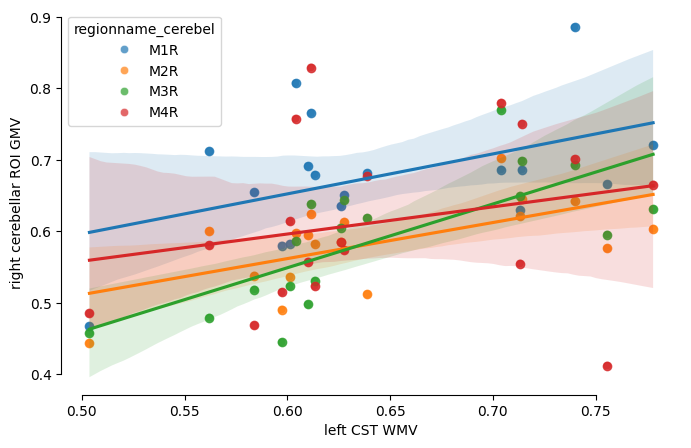

In [42]:
left_cst = cst_wm[(cst_wm.hemisphere == 'L')&(cst_wm.Week == 52)] # contralesional CST
right_cerebel = cerebel_gm[(cerebel_gm.hemisphere == 'R') & (cerebel_gm.Week == 0)] # ipsilesional cerebellum
left_df = pd.merge(left_cst, right_cerebel, on = ['subj_id'], suffixes = ('_cst', '_cerebel'))

fig, ax = plt.subplots(figsize = (8,5))
sns.scatterplot(x = left_df['mean_cst'], y=left_df['mean_cerebel'], hue = left_df['regionname_cerebel'], alpha = .7, ax = ax)
for region in left_df['regionname_cerebel'].unique():
    sns.regplot(data = left_df[left_df['regionname_cerebel'] == region], x = 'mean_cst', y = 'mean_cerebel',  ax = ax)

plt.xlabel("left CST WMV")
plt.ylabel("right cerebellar ROI GMV")

sns.despine(trim = True)
plt.show()

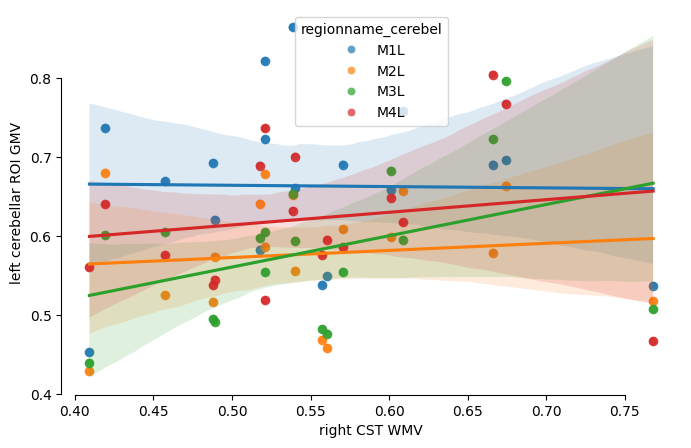

In [43]:
right_cst = cst_wm[(cst_wm.hemisphere == 'R')&(cst_wm.Week == 52)] # ipsilesional CST
left_cerebel = cerebel_gm[(cerebel_gm.hemisphere == 'L') & (cerebel_gm.Week == 0)] # contralesional cerebellum
right_df = pd.merge(right_cst, left_cerebel, on = ['subj_id'], suffixes = ('_cst', '_cerebel'))

fig, ax = plt.subplots(figsize = (8,5))
sns.scatterplot(x = right_df['mean_cst'], y=right_df['mean_cerebel'], hue = right_df['regionname_cerebel'], alpha = .7, ax = ax)
for region in right_df['regionname_cerebel'].unique():
    sns.regplot(data = right_df[right_df['regionname_cerebel'] == region], x = 'mean_cst', y = 'mean_cerebel',  ax = ax)

plt.xlabel("right CST WMV")
plt.ylabel("left cerebellar ROI GMV")

sns.despine(trim = True)
plt.show()